In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("D:\\AshleshaRuchika\\PGCP-AI\\NLP\\Day5\\UpdatedResumeDataSet.csv")

In [3]:
df

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."
...,...,...
957,Testing,Computer Skills: â¢ Proficient in MS office (...
958,Testing,â Willingness to accept the challenges. â ...
959,Testing,"PERSONAL SKILLS â¢ Quick learner, â¢ Eagerne..."
960,Testing,COMPUTER SKILLS & SOFTWARE KNOWLEDGE MS-Power ...


In [4]:
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [5]:
 print(df.iloc[0,1])

Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details 

Data Science Assurance Associate 

Data Science Assurance Associate - Ernst & Young LLP
Skill Details 
JAVASCRIPT- Exprience - 24 months
jQuery- Exprience - 24 months
Python- Exprience - 24 monthsCompany Details 
company - Ernst & Young LLP
description - Fraud Investigations and Dispute Services   Assur

## seperate the input and output variables

In [6]:
# input
x=df['Resume']

#output
y=df['Category']

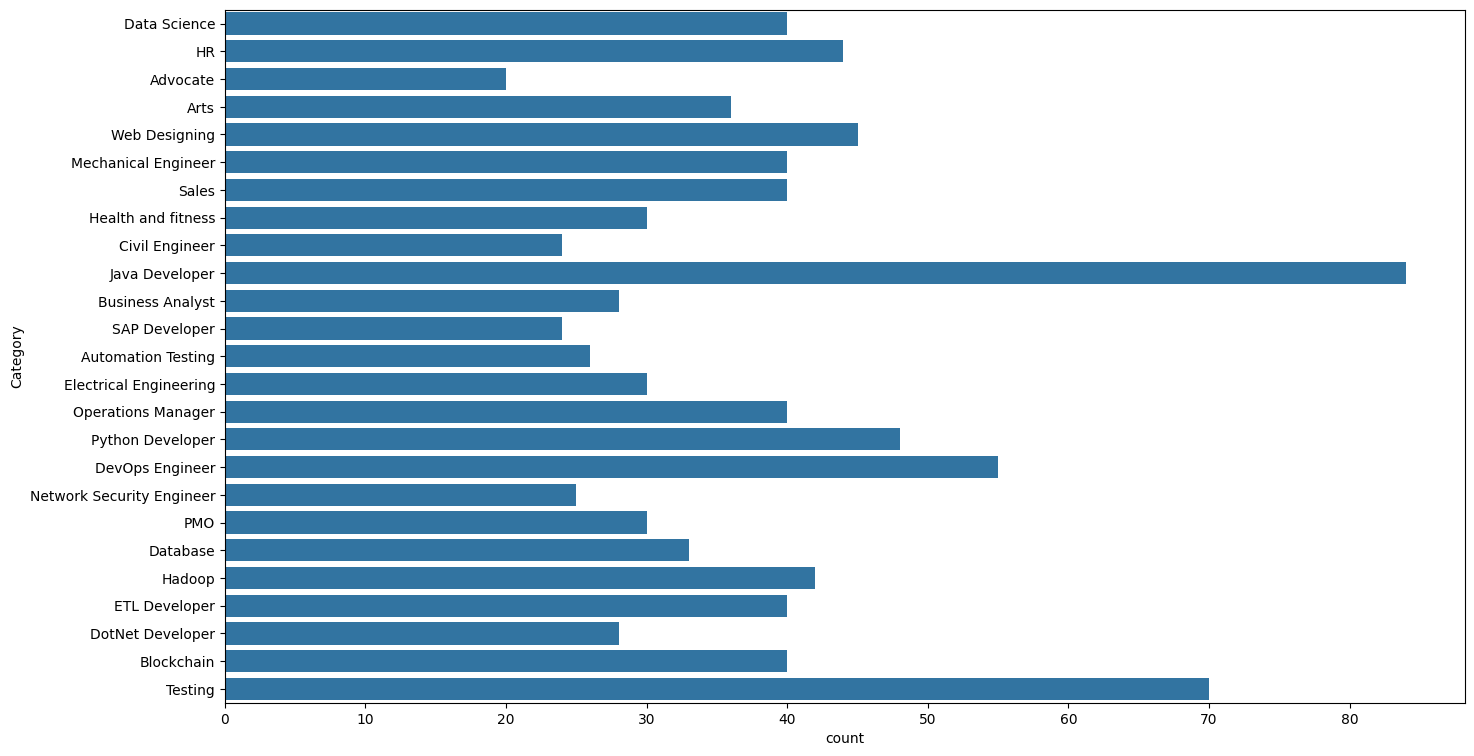

In [7]:
plt.figure(figsize=(16,9))
sns.countplot(y=y);

In [8]:
y.value_counts()

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Data Science                 40
Mechanical Engineer          40
Sales                        40
Operations Manager           40
ETL Developer                40
Blockchain                   40
Arts                         36
Database                     33
Health and fitness           30
Electrical Engineering       30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64

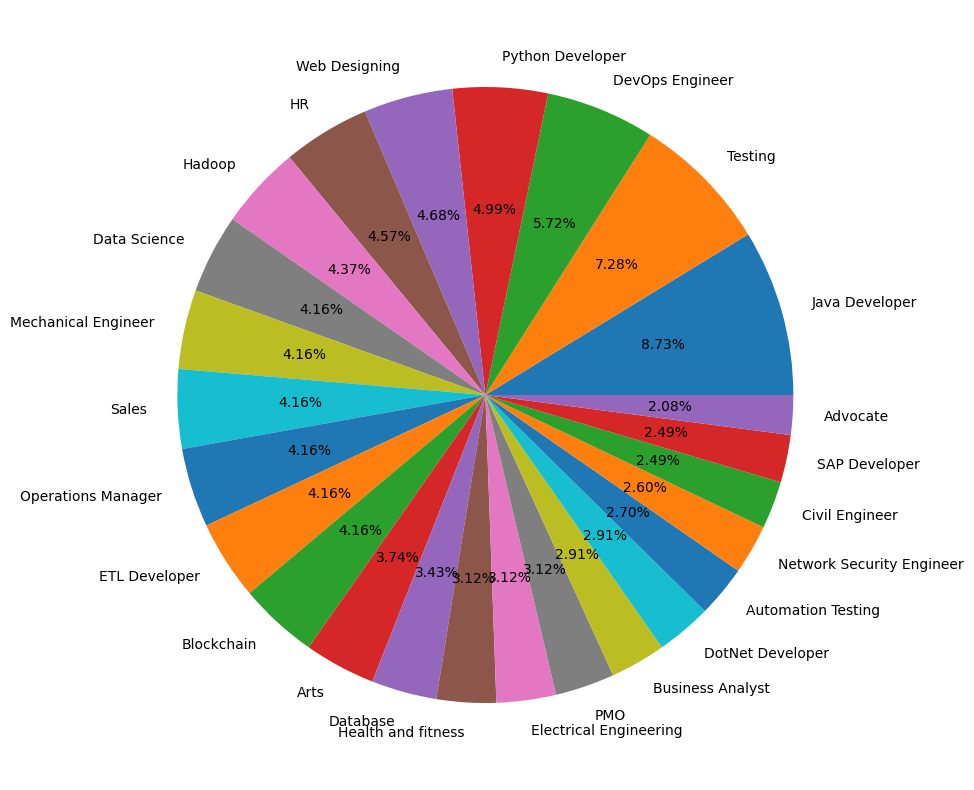

In [14]:
plt.figure(figsize=(10,10))
plt.pie(y.value_counts(),labels=y.value_counts().index,autopct='%2.2f%%');

## Define the cleaning function


In [18]:
import re,string


In [25]:
def cleanResume(text):
    text=re.sub(r'http\S+\s*',' ', text) #URLS
    text=re.sub('RT|cc',' ', text) #RT/CC
    text=re.sub(r'#\S+',' ', text) #Remove hashtags
    text=re.sub(r'@\S+',' ', text) #rRemove mentions
    text=re.sub('[%s]' %re.escape(string.punctuation), ' ',text) ## puntuation
    text=re.sub(r'[^\x00-\x7f]',r' ', text) 
    text=re.sub(r'\s+',' ',text)
    return text

In [26]:
sent = 'हेलो @Mahesh how are you?\nHave you seen https://fb.com #trend?'

In [27]:
cleanResume(sent)

' how are you Have you seen '

In [28]:
cleanResume(x[3])

'Skills R Python SAP HANA Tableau SAP HANA SQL SAP HANA PAL MS SQL SAP Lumira C Linear Programming Data Modelling Advance Analytics SCM Analytics Retail Analytics Social Media Analytics NLP Education Details January 2017 to January 2018 PGDM Business Analytics Great Lakes Institute of Management Illinois Institute of Technology January 2013 Bachelor of Engineering Electronics and Communication Bengaluru Karnataka New Horizon College of Engineering Bangalore Visvesvaraya Technological University Data Science Consultant Consultant Deloitte USI Skill Details LINEAR PROGRAMMING Exprience 6 months RETAIL Exprience 6 months RETAIL MARKETING Exprience 6 months SCM Exprience 6 months SQL Exprience Less than 1 year months Deep Learning Exprience Less than 1 year months Machine learning Exprience Less than 1 year months Python Exprience Less than 1 year months R Exprience Less than 1 year monthsCompany Details company Deloitte USI description The project involved analysing historic deals and com

In [29]:
cleaned=x.apply(cleanResume)

In [30]:
cleaned

0      Skills Programming Languages Python pandas num...
1      Education Details May 2013 to May 2017 B E UIT...
2      Areas of Interest Deep Learning Control System...
3      Skills R Python SAP HANA Tableau SAP HANA SQL ...
4      Education Details MCA YMCAUST Faridabad Haryan...
                             ...                        
957    Computer Skills Proficient in MS office Word B...
958     Willingness to a ept the challenges Positive ...
959    PERSONAL SKILLS Quick learner Eagerness to lea...
960    COMPUTER SKILLS SOFTWARE KNOWLEDGE MS Power Po...
961    Skill Set OS Windows XP 7 8 8 1 10 Database MY...
Name: Resume, Length: 962, dtype: str

In [32]:
cleaned_data=cleaned.sum()

In [33]:
len(cleaned_data)

2803381

## wordcloud visuallization

In [35]:
!pip install wordcloud -U

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [39]:
from wordcloud import WordCloud

In [43]:
wcloud=WordCloud(max_words=100).generate(cleaned_data)

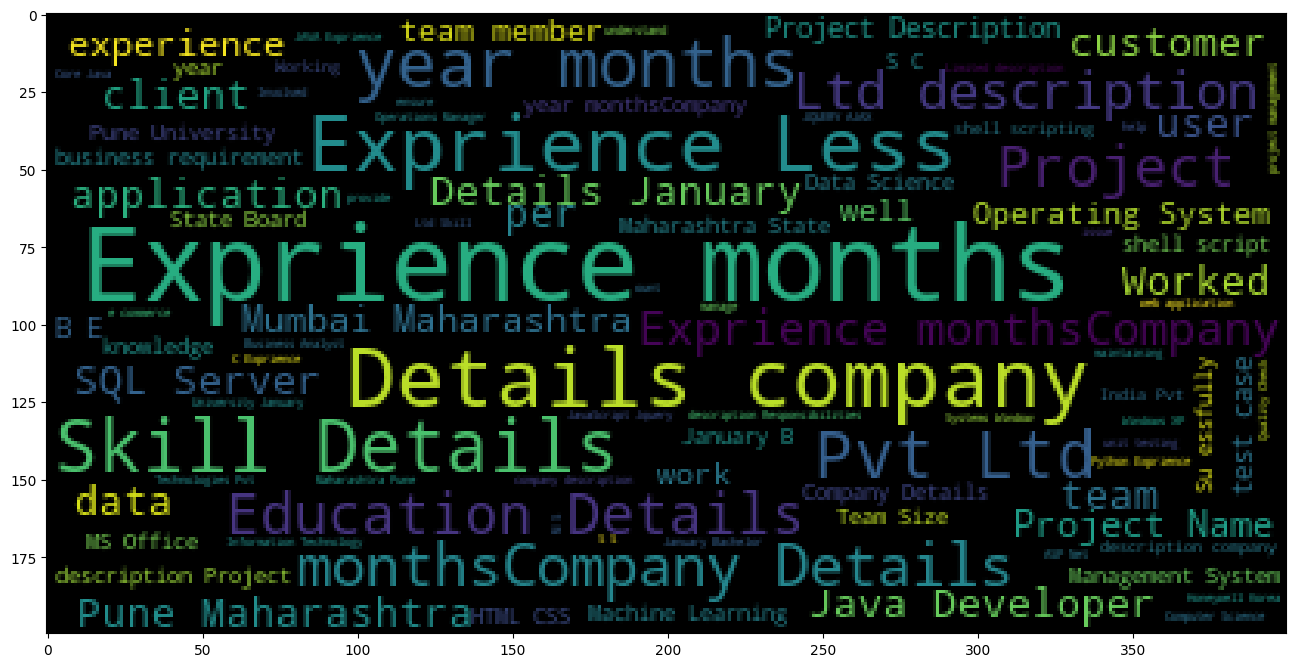

In [44]:
plt.figure(figsize=(16,9))
plt.imshow(wcloud)

In [45]:
from nltk.tokenize import word_tokenize

In [46]:
word_tokenize(cleaned_data).count('Experience Less')

0

In [47]:
new_data=" ".join(word_tokenize(cleaned_data))

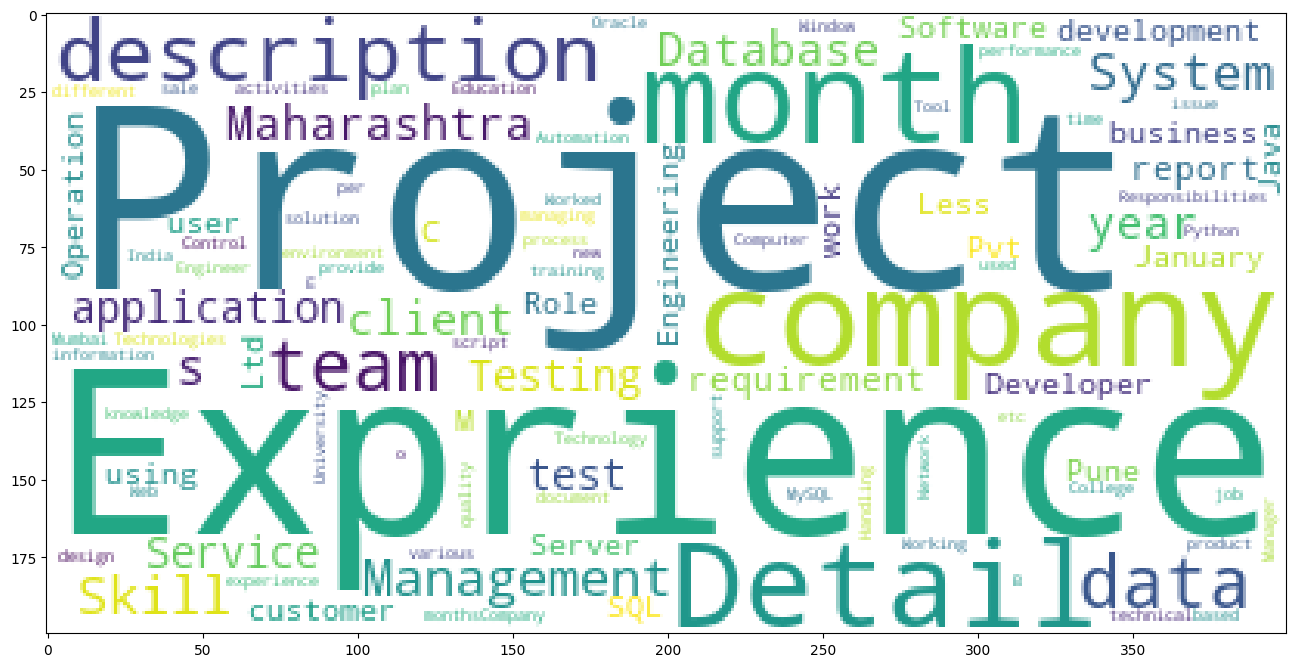

In [50]:
wcloud = WordCloud(max_words=100,collocations= False,background_color="white").generate(new_data)
plt.figure(figsize=(16,9))
plt.imshow(wcloud)

In [51]:
wcloud.words_

{'Project': 1.0,
 'Exprience': 0.9405551461557357,
 'company': 0.8779169737165315,
 'month': 0.8214197985752886,
 'Detail': 0.7693441414885778,
 'description': 0.7668877425693933,
 'team': 0.5303365266519283,
 'data': 0.5251780889216409,
 'Management': 0.4971751412429379,
 'Skill': 0.48882338491771066,
 'System': 0.47752394988946206,
 's': 0.4092360599361336,
 'Database': 0.3765659543109801,
 'year': 0.3682141979857529,
 'client': 0.3601080815524441,
 'Maharashtra': 0.3559322033898305,
 'application': 0.3424220093343159,
 'Service': 0.3377548513878654,
 'Testing': 0.33136821419798573,
 'test': 0.31859493981822645,
 'requirement': 0.3129452223041022,
 'report': 0.30189142716777206,
 'development': 0.29575042986981087,
 'business': 0.2937853107344633,
 'Server': 0.2937853107344633,
 'Developer': 0.2932940309506264,
 'customer': 0.28936379267993123,
 'Ltd': 0.2891181527880128,
 'Less': 0.28125767624662246,
 'using': 0.27609923851633505,
 'SQL': 0.27511667894866126,
 'January': 0.267747482

## Data preaparation

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [54]:
tfidf= TfidfVectorizer(stop_words="english")

In [65]:
x_vectorized = tfidf.fit_transform(x)

In [55]:
tfidf.fit_transform(cleaned)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 164261 stored elements and shape (962, 7351)>

In [67]:
tfidf.get_feature_names_out()

array(['000', '01', '017', ..., 'zz', 'ã¼', 'ã¼â'],
      shape=(7384,), dtype=object)

## cross validation

In [68]:
from sklearn.model_selection import train_test_split

In [69]:
x_train, x_test, y_train, y_test = train_test_split(x_vectorized , y, random_state=0)

## Build the model

In [74]:
from sklearn.neighbors import NearestCentroid

In [75]:
nc = NearestCentroid()

In [76]:
nc.fit(x_train, y_train)

C:\Users\PGCP-AI\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neighbors\_nearest_centroid.py:241: UserWarning: self.within_class_std_dev_ has at least 1 zero standard deviation.Inputs within the same classes for at least 1 feature are identical.
  warnings.warn(


,"metric metric: {""euclidean"", ""manhattan""}, default=""euclidean""Metric to use for distance computation.If `metric=""euclidean""`, the centroid for the samples corresponding to eachclass is the arithmetic mean, which minimizes the sum of squared L1 distances.If `metric=""manhattan""`, the centroid is the feature-wise median, whichminimizes the sum of L1 distances... versionchanged:: 1.5 All metrics but `""euclidean""` and `""manhattan""` were deprecated and now raise an error... versionchanged:: 0.19 `metric='precomputed'` was deprecated and now raises an error",'euclidean'
,"shrink_threshold shrink_threshold: float, default=NoneThreshold for shrinking centroids to remove features.",None
,"priors priors: {""uniform"", ""empirical""} or array-like of shape (n_classes,), default=""uniform""The class prior probabilities. By default, the class proportions areinferred from the training data... versionadded:: 1.6",'uniform'


In [77]:
from sklearn.metrics import classification_report, accuracy_score

In [78]:
y_pred = nc.predict(x_test)

In [79]:
accuracy_score(y_test, y_pred)

0.9875518672199171

In [80]:
print(classification_report(y_test, y_pred))

                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         4
                     Arts       1.00      1.00      1.00         3
       Automation Testing       0.83      0.83      0.83         6
               Blockchain       1.00      1.00      1.00        10
         Business Analyst       1.00      1.00      1.00        10
           Civil Engineer       1.00      1.00      1.00         9
             Data Science       1.00      1.00      1.00        11
                 Database       1.00      1.00      1.00         8
          DevOps Engineer       1.00      0.85      0.92        13
         DotNet Developer       1.00      1.00      1.00        10
            ETL Developer       1.00      1.00      1.00        11
   Electrical Engineering       0.91      1.00      0.95        10
                       HR       1.00      1.00      1.00         8
                   Hadoop       1.00      1.00      1.00     

In [95]:
f=open('Sample_resume.txt')
resume=f.read()

In [96]:
resume=tfidf.transform([resume])

In [97]:
nc.predict(resume)

array(['Data Science'], dtype=object)

In [103]:
!pip install python-docx

In [104]:
import docx

In [105]:
doc=docx.Document('SPP.docx')
doc

In [106]:
text=''
for para in doc.paragraphs:
    text+=' '+para.text
text

' Mr. Satish Prakashrao Pise Email – satish.pise.sgp@gmail.com\t\t\t\tContact No. 9096679875,7768962144 Objective Work with professional organization and contribute my excellent work with result oriented performance for continuous improvement in quality and development.   Experience – 6.3 Years Current working in Sanjay Ghodawat Polytechnic, Kolhapur. Post-Lecturer  Duration- 4.3 years, 1st June 2013 to till date Responsibilities - Teaching, guiding, motivating students as a class teacher, lecturer, and working as a lab in-charge, spoken tutorial project, IIT Bombay coordinator. Organizing and conducting trainings for students. Subject Taught – RDBMS, CNE, CMF, CHM, CHN, NMA, LPR, DLS, GUI, BWP. Samarth Polytechnic Belhe, Pune Post-Lecturer(Ad-hoc) Duration-8months, August 2012 to April 2013 Responsibilities – Teaching. Subject Taught – CMF, MIS, MAN Late. N.B. Chhabada Institute of Engineering and Technology, Satara Post-Lecturer(Ad-hoc)  Duration-1 year, August 2011 to July 2012 Resp

In [107]:
test_new1=tfidf.transform([text])

In [108]:
y_pred=nc.predict(test_new1)
y_pred

array(['Arts'], dtype=object)